<a href="https://colab.research.google.com/github/lamaljalal/ImageProcessing/blob/main/Lab4_Intensity_Transformations_%26Filtering_Spatial_Domain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


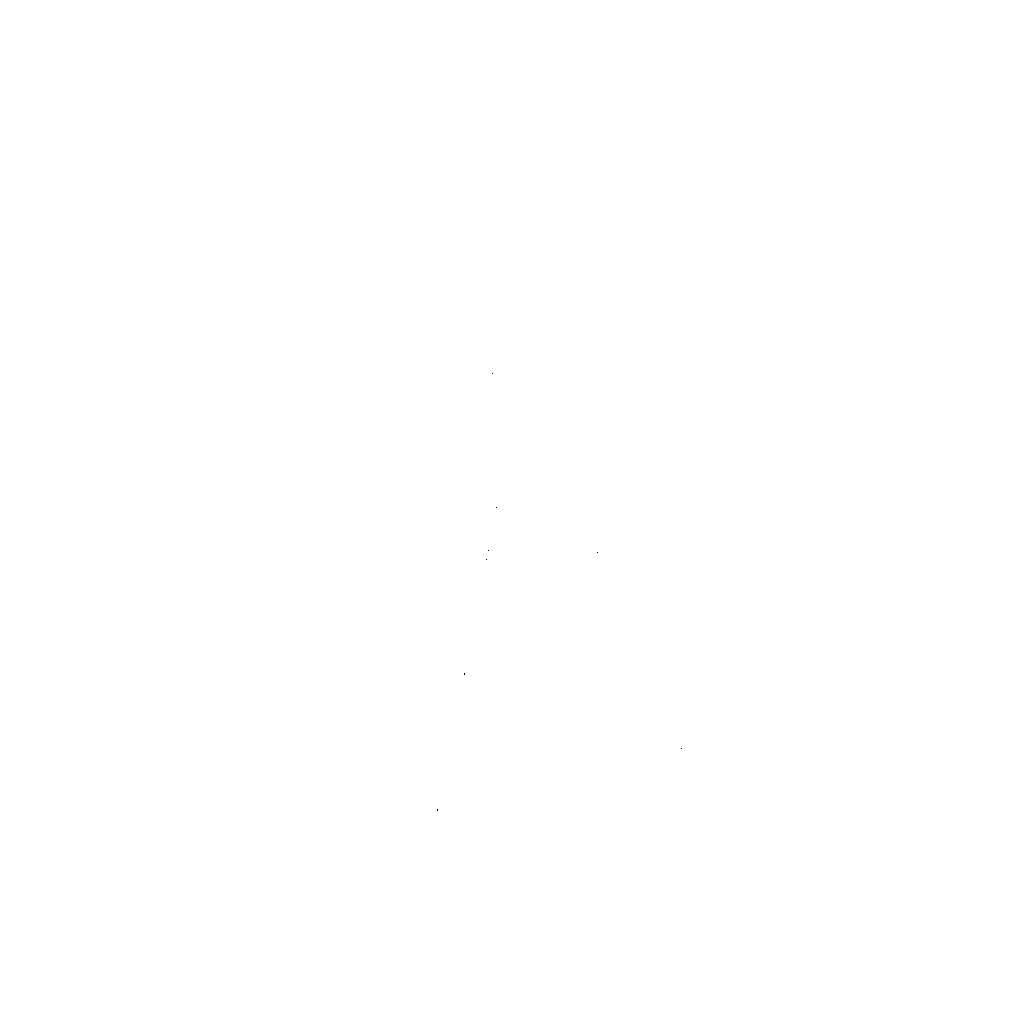

Threshold value: 50


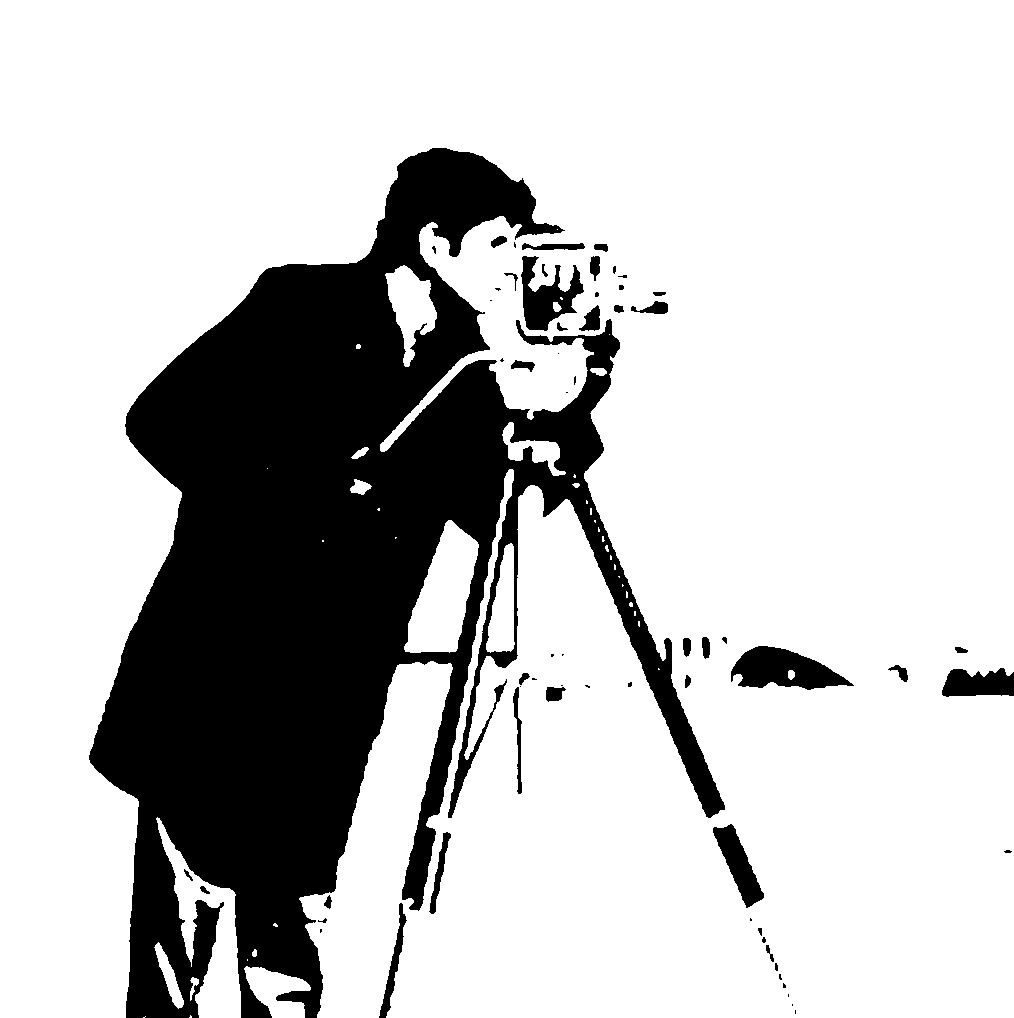

Threshold value: 100


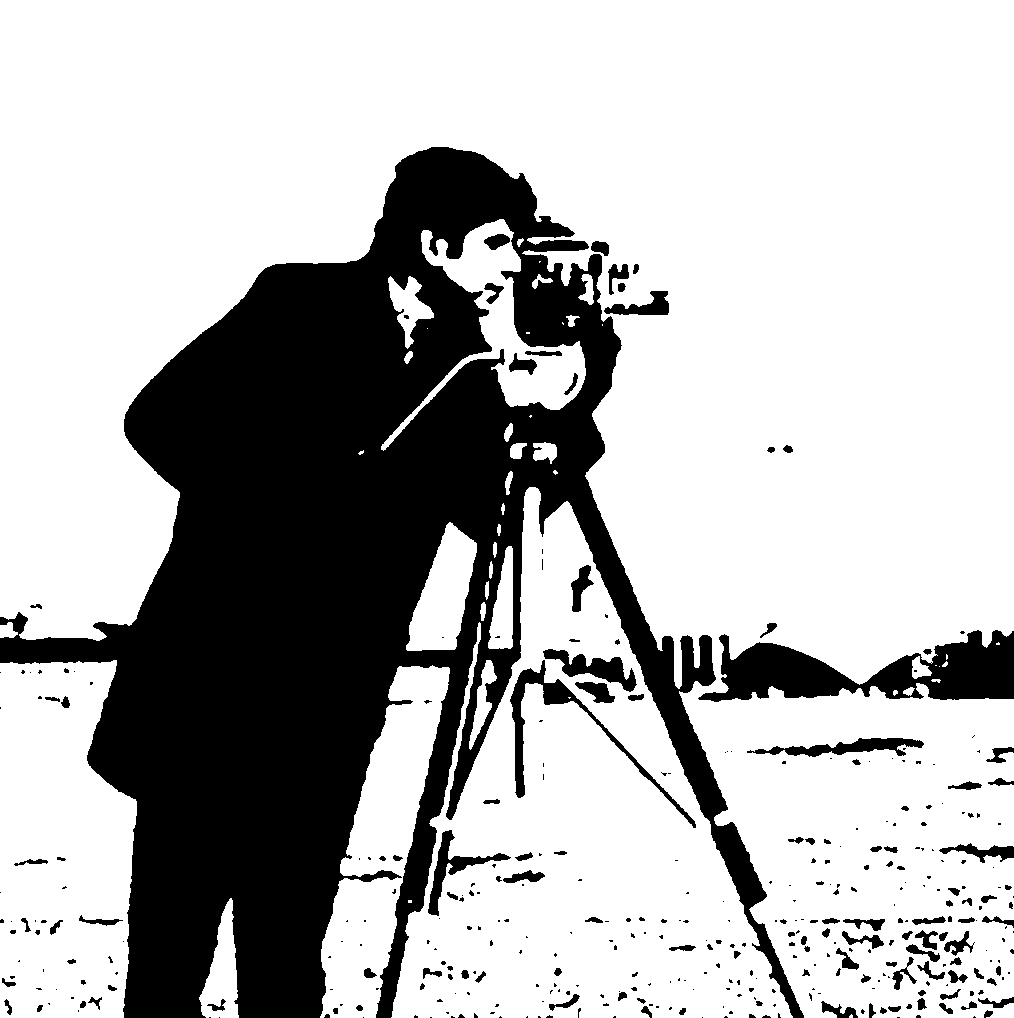

Threshold value: 150


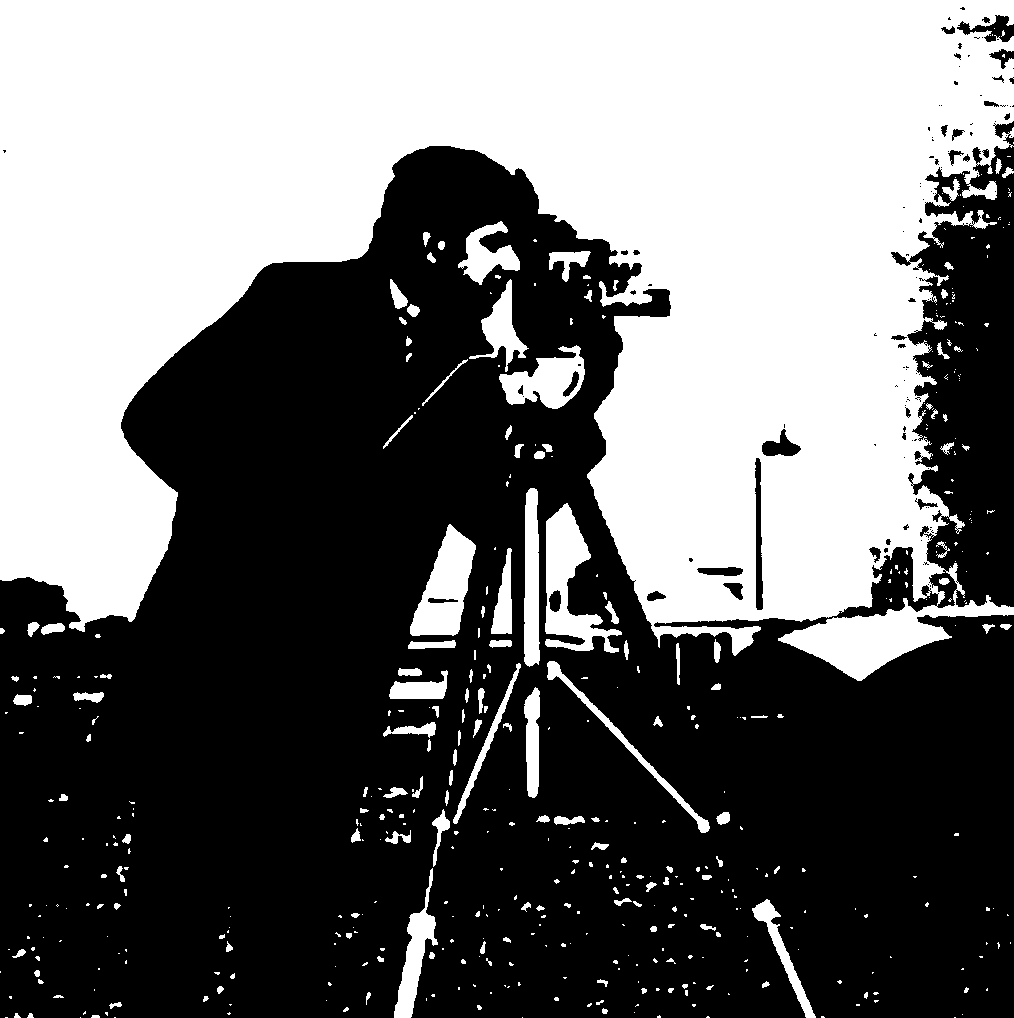

Threshold value: 200


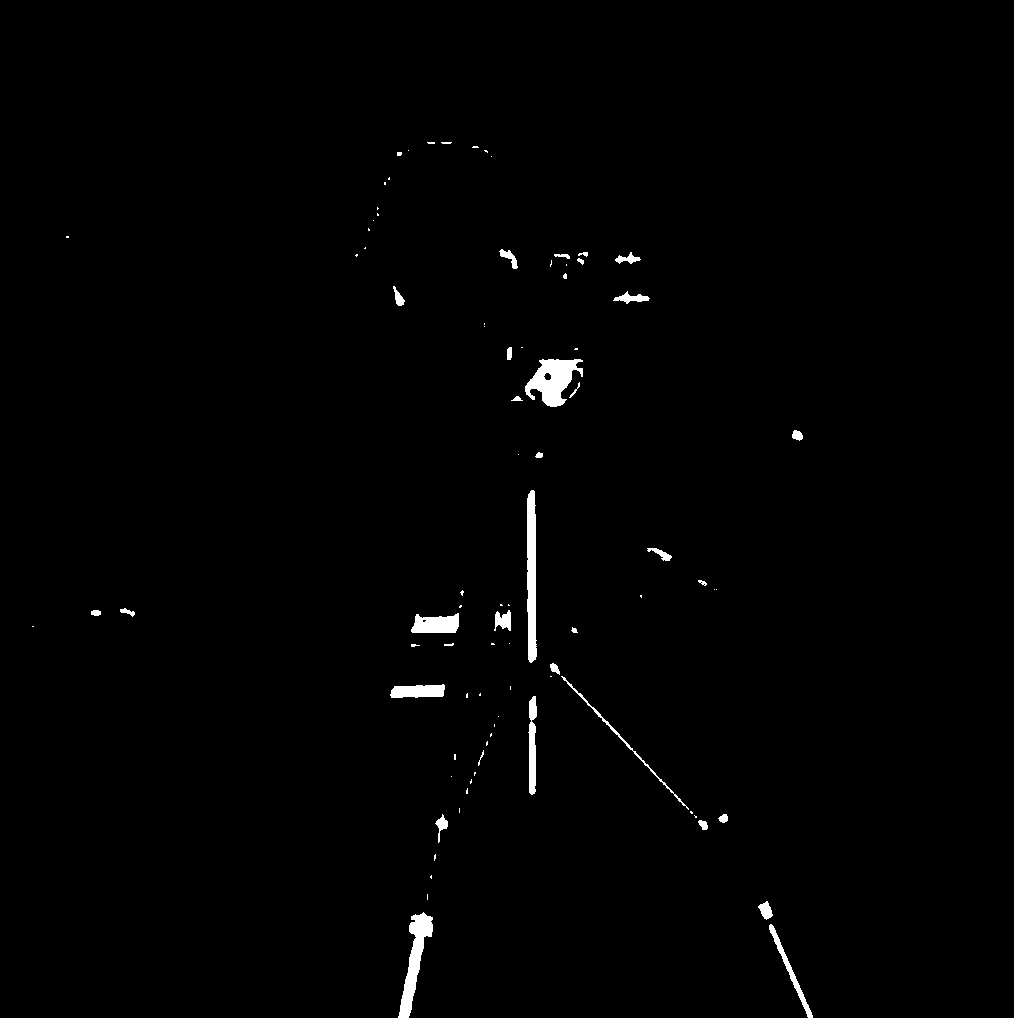

In [4]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)
threshold_values = [0, 50, 100, 150, 200]

for threshold_value in threshold_values:
    _, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)


Original Image:


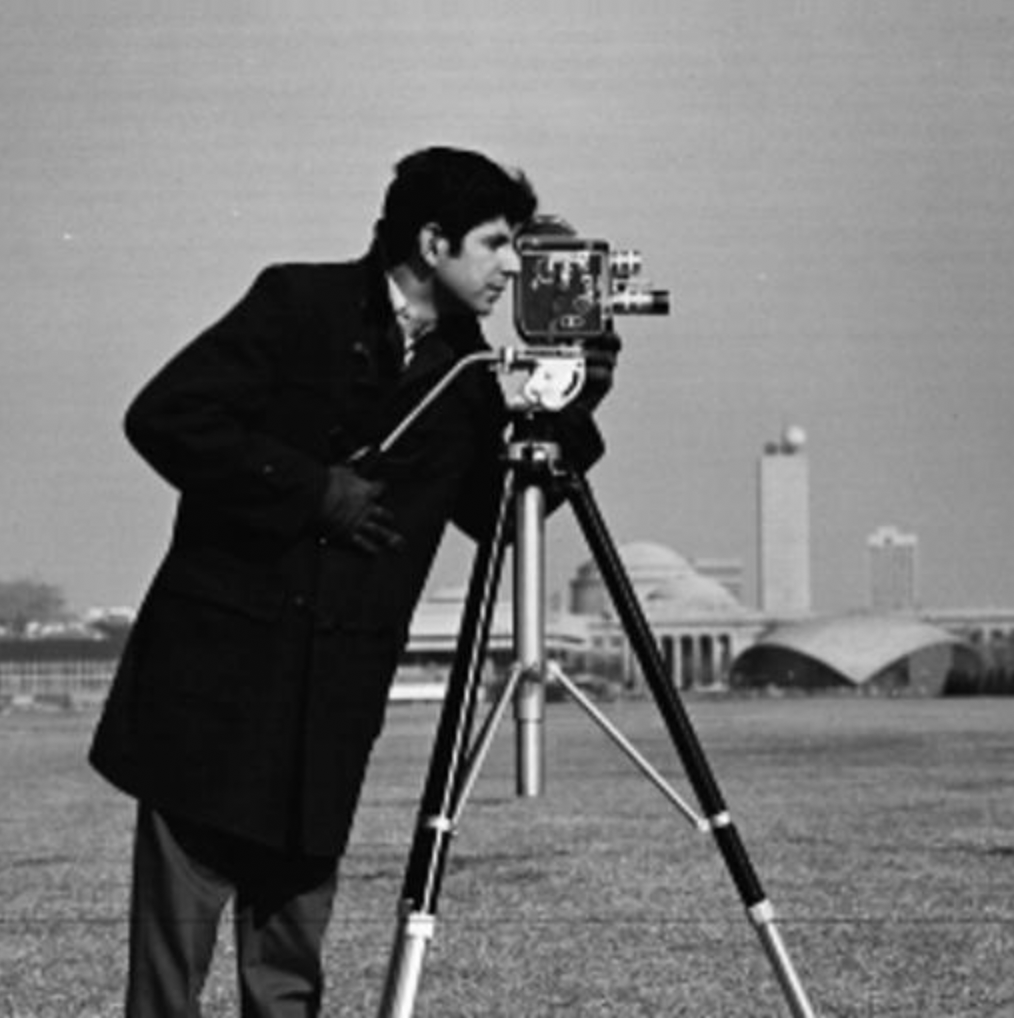

In [5]:
print("Original Image:")
cv2_imshow(img)


## Histograms

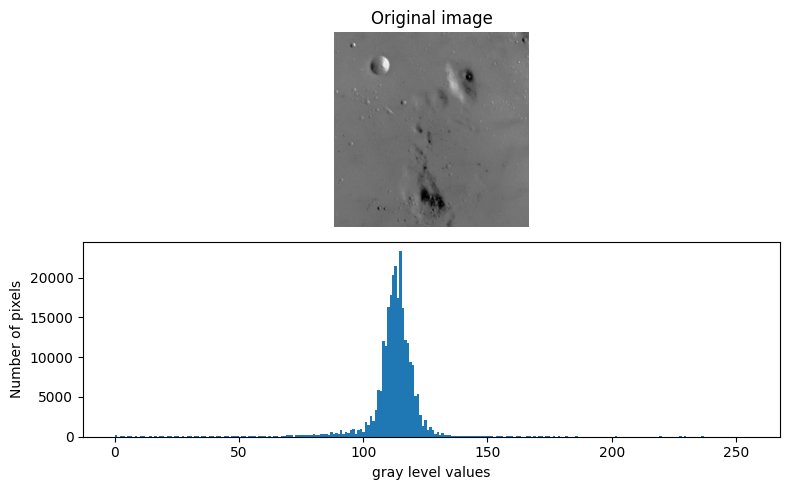

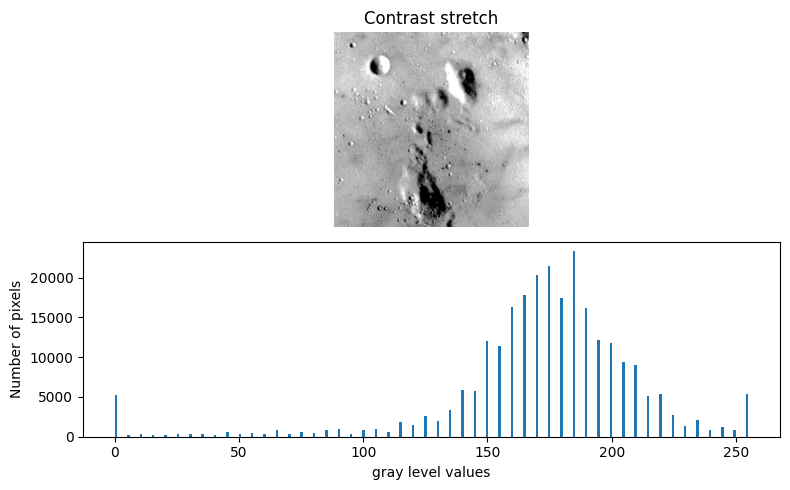

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, exposure

img = data.moon()
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.ravel(), bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.ravel(), bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.tight_layout()
plt.show()


# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


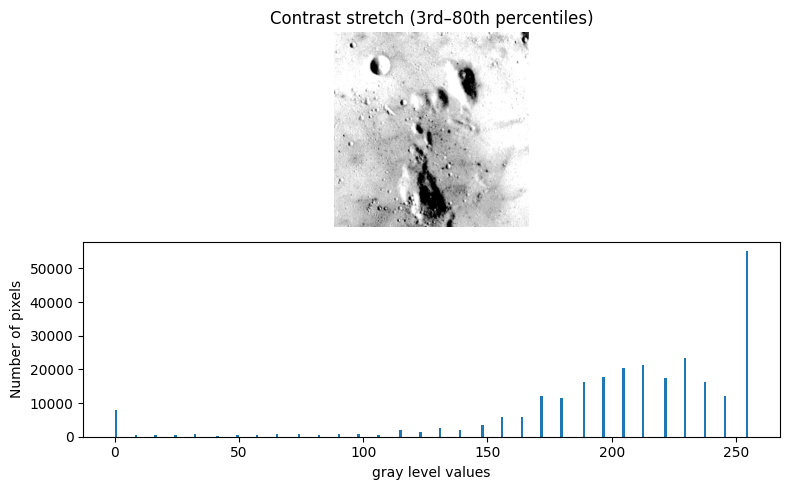

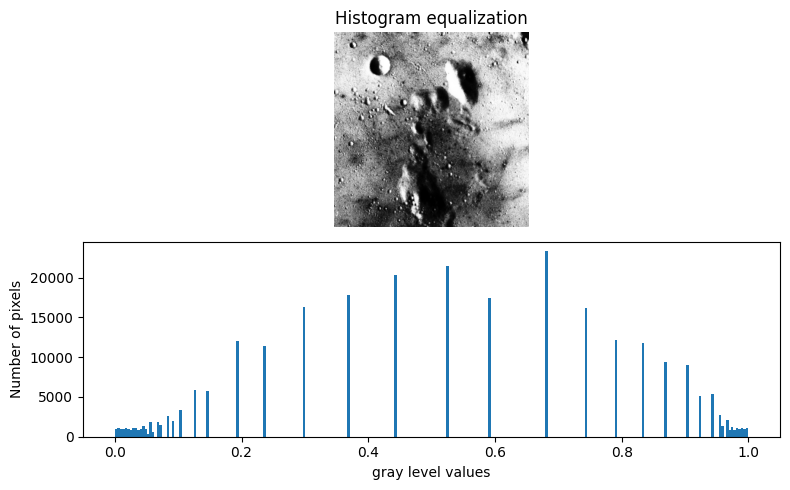

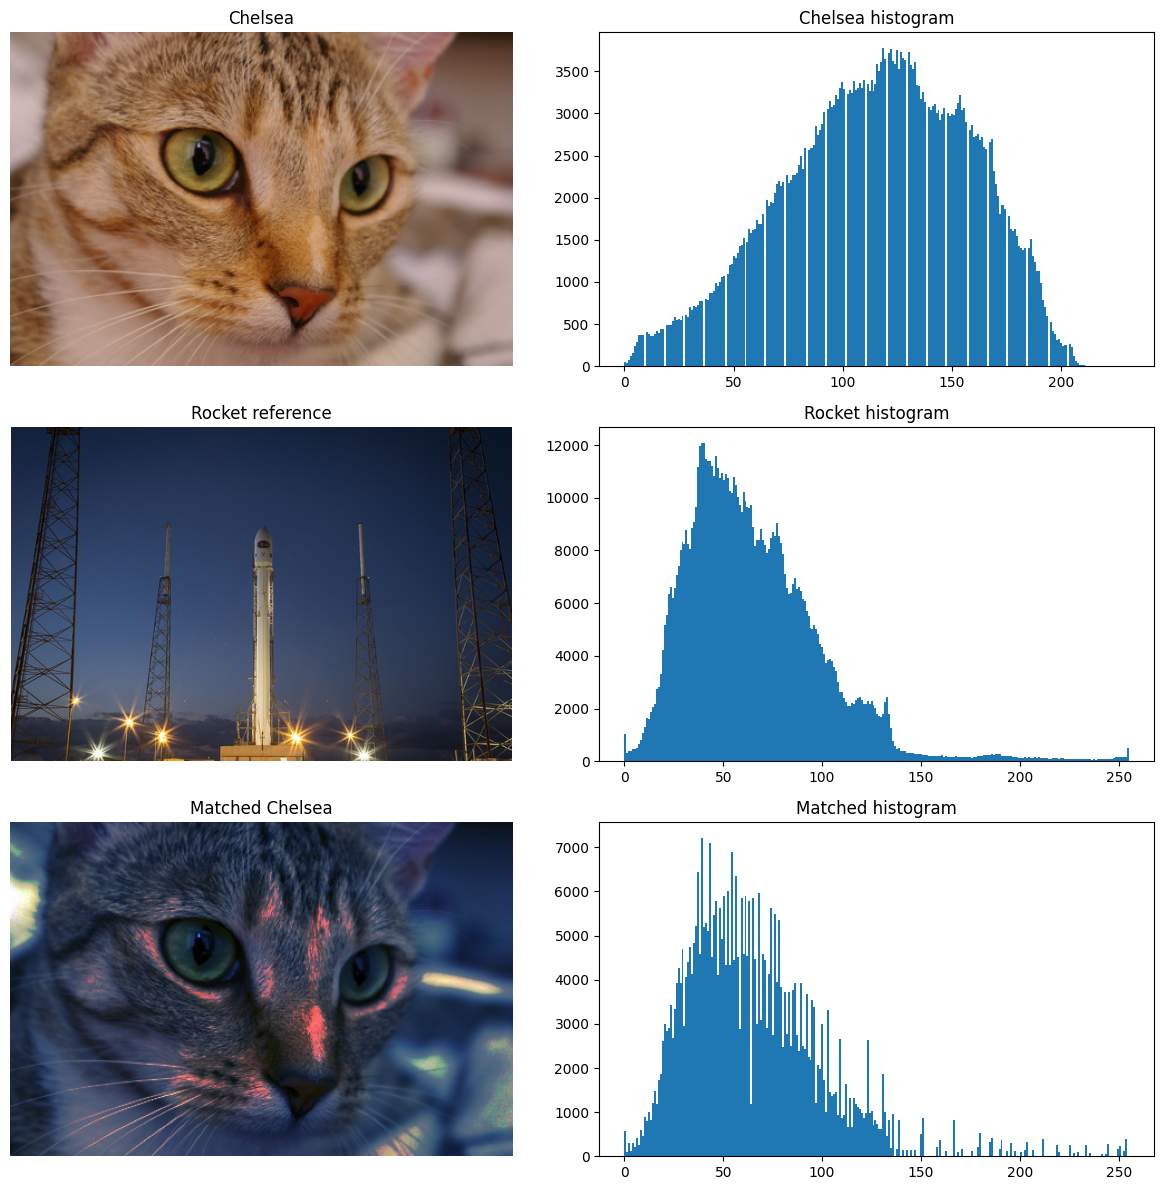

In [7]:
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd–80th percentiles)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.ravel(), bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.tight_layout()
plt.show()

img_equalized = exposure.equalize_hist(img)

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_equalized, cmap='gray')
plt.axis('off')
plt.title('Histogram equalization')
fig.add_subplot(2, 1, 2)
plt.hist(img_equalized.ravel(), bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.tight_layout()
plt.show()

reference = data.rocket()
chelsea = data.chelsea()
matched = exposure.match_histograms(chelsea, reference, channel_axis=-1)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes[0, 0].imshow(chelsea)
axes[0, 0].set_title('Chelsea')
axes[0, 0].axis('off')
axes[0, 1].hist(chelsea.ravel(), bins=256)
axes[0, 1].set_title('Chelsea histogram')
axes[1, 0].imshow(reference)
axes[1, 0].set_title('Rocket reference')
axes[1, 0].axis('off')
axes[1, 1].hist(reference.ravel(), bins=256)
axes[1, 1].set_title('Rocket histogram')
axes[2, 0].imshow(np.clip(matched, 0, 255).astype(np.uint8))
axes[2, 0].set_title('Matched Chelsea')
axes[2, 0].axis('off')
axes[2, 1].hist(matched.ravel(), bins=256)
axes[2, 1].set_title('Matched histogram')
plt.tight_layout()
plt.show()
